In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint

from sklearn.feature_selection import SelectFromModel
# !pip install imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# import warnings
# warnings.filterwarnings("ignore")

import sys
init_dir = os.getcwd()

In [3]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [4]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [5]:
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [6]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [7]:
# Cell 3: Train-validation split at consumer level
X_consumer = consumer_df.drop(columns='FPF_TARGET')
y_consumer = consumer_df['FPF_TARGET']

X_train_consumer, X_val_consumer, y_train, y_val = train_test_split(
    X_consumer, y_consumer,
    stratify=y_consumer,
    test_size=0.2,
    random_state=42
)

train_ids = X_train_consumer['masked_consumer_id']
val_ids = X_val_consumer['masked_consumer_id']


In [35]:
# Cell 4: Feature engineering from transactions

def make_transaction_features(transactions, consumer_ids):
    subset = transactions[transactions['masked_consumer_id'].isin(consumer_ids)].copy()

    # Create debit/credit indicators
    subset['is_credit'] = subset['amount'] > 0
    subset['is_debit'] = subset['amount'] < 0

    # Basic aggregate features
    agg = subset.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('is_credit', lambda x: subset.loc[x.index, 'amount'][x].sum()),
        debit_sum=('is_debit', lambda x: abs(subset.loc[x.index, 'amount'][x].sum()))
    )
    agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
    agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

    # Recent 30-day features
    subset['days_before_eval'] = (subset['evaluation_date'] - subset['posted_date']).dt.days
    recent_df = subset[subset['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
        recent30_sum=('amount', 'sum'),
        recent30_count=('amount', 'count')
    )

    # Monthly volatility
    subset['month'] = subset['posted_date'].dt.to_period('M')
    monthly_cashflow = subset.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
        columns={'mean': 'monthly_mean', 'std': 'monthly_std'})
    monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan)
    monthly_stats = monthly_stats.fillna(0)

    # Category encoding
    cat_encode = pd.get_dummies(subset, columns=['category'], drop_first=False)
    cat_cols = [col for col in cat_encode.columns if col.startswith('category_')]
    cat_encode_mean = cat_encode.groupby('masked_consumer_id')[cat_cols].sum()

    # Weekend spending
    subset['weekday'] = subset['posted_date'].dt.weekday
    subset['is_weekend'] = subset['weekday'] >= 5

    # Calculate weekend and weekday spending separately
    weekend_spend = subset[subset['amount'] > 0].groupby('masked_consumer_id').agg(
        weekday_spending=('amount', lambda x: x[~subset.loc[x.index, 'is_weekend']].sum()),
        weekend_spending=('amount', lambda x: x[subset.loc[x.index, 'is_weekend']].sum())
    )

    weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

    # Transaction frequency
    txn_freq = subset.groupby('masked_consumer_id').agg(
        unique_txn_days=('posted_date', lambda x: x.nunique()),
        txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
    )
    txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

    # Percentiles
    percentiles = subset.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
    percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

    # Large transactions
    subset['is_large'] = subset['amount'].abs() > 1000
    large_txns = subset.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

    # Monthly trend
    monthly_spend = subset.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()

    def compute_monthly_trend(df):
        if df.shape[0] < 2:
            return 0
        df = df.sort_values('month')
        x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
        y = df['amount'].values
        model = LinearRegression().fit(x, y)
        return model.coef_[0]

    monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

    # Merge all features
    features_df = agg \
        .join(recent_df, how='left') \
        .join(monthly_stats, how='left') \
        .join(cat_encode_mean, how='left') \
        .join(txn_freq, how='left') \
        .join(weekend_spend, how='left') \
        .join(large_txns, how='left') \
        .join(percentiles, how='left') \
        .join(monthly_trend, how='left') \
        .fillna(0) \
        .reset_index()

    return features_df


X_train_txn = make_transaction_features(transactions_df, train_ids)
X_val_txn = make_transaction_features(transactions_df, val_ids)


/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_12536/3738300701.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_12536/3738300701.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_trend = monthly_spend.gro

In [36]:
# Cell 5: Merge transaction features into consumer-level data
X_train = X_train_consumer.merge(X_train_txn, on='masked_consumer_id', how='left')
X_val = X_val_consumer.merge(X_val_txn, on='masked_consumer_id', how='left')

# Drop identifier
X_train = X_train.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)
X_val = X_val.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)


In [136]:
# Cell 6: Lasso + SMOTE + Logistic Regression pipeline
pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),  # normalize
    ('smote', SMOTE(random_state=42)),  # balance classes
    # ('feature_select', SelectFromModel(LogisticRegression(
    #     penalty='l1', C=0.01, solver='saga', class_weight='balanced', random_state=42, max_iter=1000))),
    # ('model', LogisticRegression(
    #     penalty='l2', C=0.01, solver='saga', class_weight='balanced', random_state=42, max_iter=1000)),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42))
])
# neg, pos = np.bincount(y_train)
# scale = neg / pos  # e.g., if 99% zeros, scale ≈ 99
# print(scale)
# # 2. Define pipeline with XGBoost + scale_pos_weight
# pipeline = ImbPipeline(steps=[
#     ('scaler', StandardScaler()),
#     ('smote', SMOTE(random_state=42)),  # you can also remove this to let scale_pos_weight do the job alone
#     ('model', XGBClassifier(
#         use_label_encoder=False,
#         eval_metric='auc',
#         random_state=42,
#         scale_pos_weight=scale
#     ))
# ])

# param_dist = {
#     'model__n_estimators': [100, 200, 300],
#     'model__max_depth': [3, 5, 7, 9],
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__colsample_bytree': [0.6, 0.8, 1.0],
#     'model__min_child_weight': [1, 3, 5]
# }
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(3, 10),
}

# # Randomized search
# search = RandomizedSearchCV(
#     pipeline,
#     param_distributions=param_distributions,
#     n_iter=50,
#     scoring='roc_auc',
#     n_jobs=-1,
#     cv=3,
#     random_state=42,
#     verbose=1
# )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=50,  # tune as needed
    # cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search = pipeline



In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(xgb_model, feature_names, top_n=20, importance_type='gain'):
    """
    Plot top N XGBoost feature importances using the specified importance type.
    
    Parameters:
    - xgb_model: fitted XGBClassifier
    - feature_names: list of column names
    - top_n: number of top features to show
    - importance_type: 'weight', 'gain', 'cover', 'total_gain', or 'total_cover'
    """
    booster = xgb_model.get_booster()
    importance = booster.get_score(importance_type=importance_type)
    importance_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    })

    # Align with original feature names (in case of preprocessing)
    importance_df['feature'] = importance_df['feature'].map(lambda x: feature_names[int(x[1:])] if x.startswith('f') else x)

    top_features = importance_df.sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=top_features)
    plt.title(f'Top {top_n} XGBoost Features ({importance_type})')
    plt.tight_layout()
    plt.show()


In [138]:
X_train.columns.shape

(63,)

In [139]:
# Cell 7: Fit model and evaluate
search.fit(X_train, y_train)

y_val_proba = search.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba)
# print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Validation AUC: {val_auc:.4f}")
# print("Best parameters:", search.best_params_)
print(classification_report(y_val, y_val_proba > 0.01))
# plot_xgb_feature_importance(search.best_estimator_.named_steps['model'], feature_names=X_train.columns)

/opt/miniconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:53:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation AUC: 0.6683
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.95       788
         1.0       0.04      0.25      0.07        12

    accuracy                           0.91       800
   macro avg       0.52      0.58      0.51       800
weighted avg       0.97      0.91      0.94       800



Model Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}

Top 10 Most Important Feature

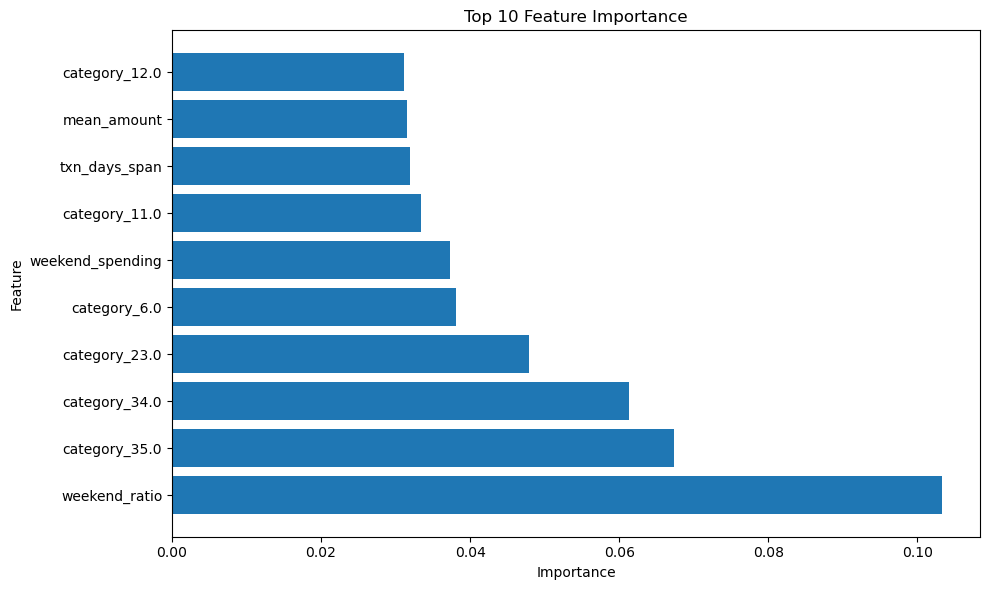

In [140]:
# 1. Get the model from the pipeline
model = search.named_steps['model']

# 2. Get model parameters
print("Model Parameters:")
print(model.get_params())

# 3. Get feature importance
# For XGBoost, you can get feature importance in different ways:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,  # Make sure X_train has the same columns as your training data
    'importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Display top features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Optional: Visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [141]:
# from sklearn.metrics import precision_recall_curve

# prec, rec, thresholds = precision_recall_curve(y_val, y_val_proba)
# for t, p, r in zip(thresholds[::20], prec[::20], rec[::20]):
#     print(f"Threshold: {t:.2f}, Precision: {p:.2f}, Recall: {r:.2f}")


In [142]:
# import matplotlib.pyplot as plt

# plt.hist(y_val_proba[y_val == 1], bins=30, alpha=0.6, label='Positive')
# plt.hist(y_val_proba[y_val == 0], bins=30, alpha=0.6, label='Negative')
# plt.axvline(0.5, color='red', linestyle='--')
# plt.legend()
# plt.title("Validation prediction probabilities")
# plt.show()


In [143]:
# y_train_pred_proba = search.predict_proba(X_train)[:, 1]
# train_auc = roc_auc_score(y_train, y_train_pred_proba)

# print("Training AUC:", train_auc)

In [144]:
# Cell 8 (Optional): Get selected features
# mask = pipeline.named_steps['feature_select'].get_support()
# selected_features = X_train.columns[mask]
# print("Selected features:", selected_features.tolist())


In [145]:
# mask.sum()